# How to combine two exceedance curves

In this notebook, we show different ways how to combine exceedance curves. The central objects are instances of the class `ExceedanceCurve`, each of which includes an array of `exceedance_frequencies` (equal to `1/return_periods`) and the corresponding `values`, in this example corresponding to monetary impacts.

One can combine a number of such exceedance curves using the method `combine_exceedance_curves`. For this, the user has to provide a number of parameters, some of which optional. These parameters include
- `aggregation_method`: how different values are to be aggregated if they occur simultaneously. For instance, a simple way to combine impacts is `sum`. Hazard intensities could e.g. be combine by `max`.
- `coincidence_fraction`: this parameter defines the time window during which two events are considered simultaneous. It is given as a fraction of the time unit with which the `exceedance_frequencies` are defined. For instance, if the `exceedance_frequencies` have in the unit `1/year`, the time unit would be one year. Choosing, e.g., `coincidence_fraction = 1/12` would mean that we consider two events simultaneous if they occur in a during the timespan of one month.

The exceedance curves are combined using a sampling approach by default (`use_sampling=True`; the analytic approach is also available but the implementation still has to be improved as it is very slow). The sampling allows for further two parameters
- `n_samples`: The number of samples to be drawn to approaximate the combined exceedance curve
- `correlation_factor`: A parameter to include correlations to the sampling from the two curves. If 0 (default value), the two curves are sampled independently. If 1., sampled values are perfecly correlated (e.g., the largest values are drawn together). If -1., the sampled values are anticorrelated. 

## Define example exceedance curves

First, we define some exemplary exceedance curves. We use a rough approximation of the exceedance curves reported in Fig 3a of [Stalhandske et. al., Z., Steinmann, C.B., Meiler, S. et al. Global multi-hazard risk assessment in a changing climate]( https://doi.org/10.1038/s41598-024-55775-2) (with an option to use logarithmic curves of similar shape when setting `use_log_curves=True`).

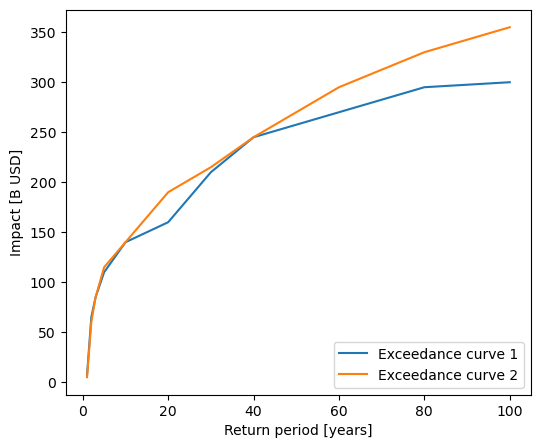

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from exceedance_curve_tools import ExceedanceCurve, combine_exceedance_curves
from exceedance_curve_tools.utils import frequency_from_exceedance_frequency

# define two example exceedance curves from paper
returnperiods_paper = np.array([1, 2, 3, 5, 10, 20, 30, 40, 60, 80, 100])
exceedancefrequencies_paper = 1/returnperiods_paper
values_paper_TC = np.array([5, 60, 85, 115, 140, 190, 215, 245, 295, 330, 355])
values_paper_RF = np.array([7, 65, 85, 110, 140, 160, 210, 245, 270, 295, 300])
values_paper_combined = np.array([20, 120, 160, 205, 240, 310, 350, 390, 430, 480, 510])

use_log_curves = False
if use_log_curves:
    returnperiods_paper = np.geomspace(1, 100, 200)
    exceedancefrequencies_paper = 1/returnperiods_paper
    values_paper_RF = 60*np.log(returnperiods_paper)
    values_paper_TC = 65*np.log(returnperiods_paper)
    values_paper_combined = 85*np.log(returnperiods_paper)

# plot exceedance curves
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(returnperiods_paper, values_paper_RF, label='Exceedance curve 1')
ax.plot(returnperiods_paper, values_paper_TC, label='Exceedance curve 2')
# ax.plot(returnperiods_paper, values_paper_combined, label='Combined exceedance curve')
ax.legend(loc='lower right')
ax.set_xlabel('Return period [years]')
ax.set_ylabel('Impact [B USD]');

# create ExceedanceCurve objects
exceedance_curve1, exceedance_curve2 = [ExceedanceCurve(
    values=values,
    exceedance_frequencies=exceedancefrequencies_paper,
) for values in [values_paper_RF, values_paper_TC]] 

## Combine two impact exceedance curves

We now demonstrate how `combine_exceedance_curves` combines the two exceedance curves with exemplary parameters.

In [2]:
coincidence_fraction = 1 # 1/12: coincident if in the same month, 1: coindident if in the same year
correlation_coefficients = {"anticorrelated": -.95, "correlated": 1, "independent": 0} # 0: independent, 1: perfectly correlated
aggregation_method = sum # we sum imapcts of coincident events
n_samples = 1000000 # number of samples to draw
exceedance_curves_combined = {label: combine_exceedance_curves(
        [exceedance_curve1, exceedance_curve2],
        aggregation_method=sum,
        coincidence_fraction=coincidence_fraction,
        correlation_factor=corr,
        n_samples=1000000
    )
    for label, corr in correlation_coefficients.items()
}

# analytic combination (only independent case)
# combined_analytic = combine_exceedance_curves(
#     [exceedance_curve1, exceedance_curve2],
#     aggregation_method=sum,
#     coincidence_fraction=coincidence_fraction,
#     use_sampling=False)

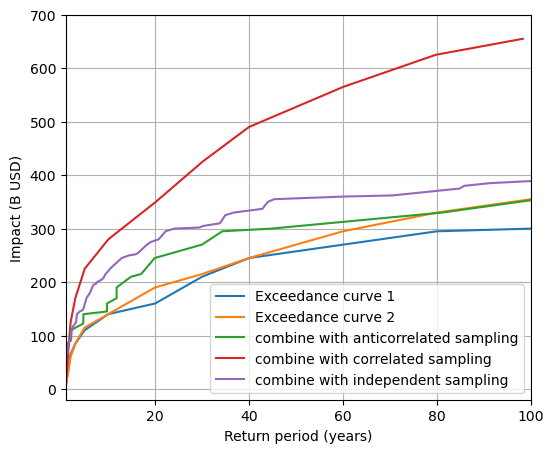

In [3]:
# plot combined exceedance curves
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(1/exceedance_curve1.exceedance_frequencies, exceedance_curve1.values, label='Exceedance curve 1')
ax.plot(1/exceedance_curve2.exceedance_frequencies, exceedance_curve2.values, label='Exceedance curve 2')
for label in exceedance_curves_combined.keys():
    ax.plot(1/exceedance_curves_combined[label].exceedance_frequencies, exceedance_curves_combined[label].values, label=f"combine with {label} sampling")
# ax.plot(1/combined_analytic.exceedance_frequencies, combined_analytic.values, label='Analytic combination')

ax.grid()
ax.legend(loc='lower right')
plt.xlabel('Return period (years)')
plt.ylabel('Impact (B USD)')
ax.set_xlim(1, 100)
ax.set_ylim(-20, 700);


#### Optional: Discussion of average annual impacts of combined curves
If we aggreagte values by summing (`aggregation_method = sum` above), the average annual impact (AAI) resulting from the combined exceedance curve should be equal to the sum of the AAI of the original exceedance curves. However, in the sampling, we have to convert frequencies to probabilities (corresponding the user-specified time window). Then, we compute the probabilities that a given value is exceeded in this time window, which neglects the possibility that there are two impacts from the same exceedance curve in the same time window (i.e., it will only consider the larger one). See this [notebook](estimate_AAI.ipynb) for more details.

Therefore, if we compute the AAIs of the combined exceedance curves, they will generally not equal the sum of the original AAIs (even if sample sizes are large). Instead, if one computes AAIs using the time window that was used in the sampling (see this [notebook](estimate_AAI.ipynb) for more details), the combined AAIs correspond to the sum of the original AAIs (provided sample sizes are large enough).

In [4]:
# CLIMADA-sytle AAI computation
aai1 = exceedance_curve1.average_annual_impact()
aai2 = exceedance_curve2.average_annual_impact()
aai_combined = {label: exceedance_curves_combined[label].average_annual_impact() for label in exceedance_curves_combined.keys()}
print('Compute AAIs with original frequencies ("CLIMADA"-style AAI computation):')
print(f"The original exceedance curves' AAIs ({aai1:.2f} and {aai2:.2f}, respectively) sum to {aai1+aai2:.2f}")
print("The combined exceedance curves' AAIs are:")
print(*[f"{aai_combined[label]:.2f} ({label} sampling)\n" for label in aai_combined.keys()], sep="")

# CLIMADA-sytle AAI computation
aai1 = exceedance_curve1.average_annual_impact(coincidence_fraction=coincidence_fraction)
aai2 = exceedance_curve2.average_annual_impact(coincidence_fraction=coincidence_fraction)
aai_combined = {label: exceedance_curves_combined[label].average_annual_impact(coincidence_fraction=coincidence_fraction) for label in exceedance_curves_combined.keys()}
print('Compute AAIs with probabilities corresponding the sampling time window:')
print(f"The original exceedance curves' AAIs ({aai1:.2f} and {aai2:.2f}, respectively) sum to {aai1+aai2:.2f}")
print("The combined exceedance curves' AAIs are:")
print(*[f"{aai_combined[label]:.2f} ({label} sampling)\n" for label in aai_combined.keys()], sep="")

Compute AAIs with original frequencies ("CLIMADA"-style AAI computation):
The original exceedance curves' AAIs (54.99 and 54.94, respectively) sum to 109.92
The combined exceedance curves' AAIs are:
181.79 (anticorrelated sampling)
109.81 (correlated sampling)
127.95 (independent sampling)

Compute AAIs with probabilities corresponding the sampling time window:
The original exceedance curves' AAIs (44.55 and 45.21, respectively) sum to 89.77
The combined exceedance curves' AAIs are:
89.61 (anticorrelated sampling)
89.68 (correlated sampling)
89.89 (independent sampling)



## Combine two impact exceedance curves: naive approaches

Two simple ways on how to combine two impact exceedance curves are
- summing the impacts for each return period. This essentially assumes that the impacts are perfectly correlated, i.e., that the highest impact of the first curve happens simultaneously with the highest impact of the second one.
- Concatenating the two impact event sets (i.e., the CLIMADA impact matrices). This assumes that the impacts of the two exceedance curves never happen simultaneously.

In our example case, this would look like the following

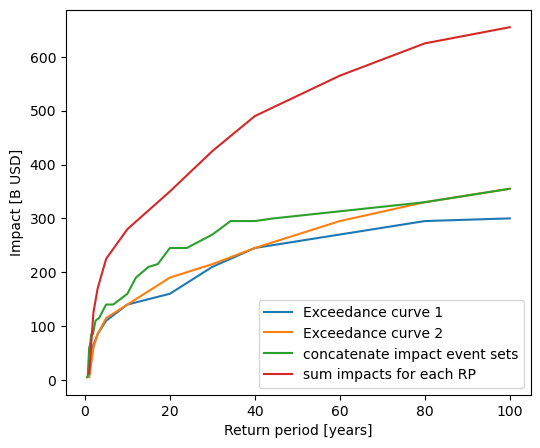

In [5]:
# summing the impacts for each return period

exceedance_curve_sum = ExceedanceCurve(values = values_paper_RF + values_paper_TC, exceedance_frequencies = exceedancefrequencies_paper)

# concatenating the two impact event sets

frequencies_concat = np.concatenate([
    frequency_from_exceedance_frequency(ex_curve.exceedance_frequencies) for ex_curve in [exceedance_curve1, exceedance_curve2]
]) # compute frequencies from exceedance frequencies and concatenate 
values_concat = np.concatenate([ex_curve.values for ex_curve in [exceedance_curve1, exceedance_curve2]]) # concatenate values
# compute combined exceedance frequencies
sorted_indices = np.argsort(values_concat)
frequencies_concat = frequencies_concat[sorted_indices]
values_concat = values_concat[sorted_indices]
exceedance_frequencies_concat = np.cumsum(frequencies_concat[::-1])[::-1]
exceedance_curve_concat = ExceedanceCurve(values = values_concat, exceedance_frequencies = exceedance_frequencies_concat)

# plot exceedance curves
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(1/exceedance_curve1.exceedance_frequencies, exceedance_curve1.values, label='Exceedance curve 1')
ax.plot(1/exceedance_curve2.exceedance_frequencies, exceedance_curve2.values, label='Exceedance curve 2')
ax.plot(1/exceedance_curve_concat.exceedance_frequencies, exceedance_curve_concat.values, label='concatenate impact event sets')
ax.plot(1/exceedance_curve_sum.exceedance_frequencies, exceedance_curve_sum.values, label='sum impacts for each RP')
# ax.plot(returnperiods_paper, values_paper_combined, label='Combined exceedance curve')
ax.legend(loc='lower right')
ax.set_xlabel('Return period [years]')
ax.set_ylabel('Impact [B USD]');